# Quadratically regularized Eqm OT experiments

This notebook combines the two original experiment notebooks into one clean experiment entry point.

It contains two solver comparisons for the same quadratically regularized Eqm OT construction:

1. **APDAGD vs Sinkhorn-type L2 coordinate updates**
2. **APDAGD vs Dual L-BFGS solver**

The problem definitions and solvers are kept in separate Python modules. This notebook focuses on experiment configuration, running, summarizing, and plotting.

## 1. Imports and paths

Place this notebook in the same folder as `base.py`, `euclidean.py`, `apdagd.py`, `sinkhorn.py`, and `dual_l2_solver.py`.

In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path
from typing import Any, Dict, Iterable, List, Sequence

import matplotlib.pyplot as plt
import numpy as np

# Make local project modules importable when the notebook is run from its folder.
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from apdagd import APDAGD
from sinkhorn import Sinkhorn
from dual_l2_solver import DualL2Solver
from euclidean import solve_nested_euclidean_ot

PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Plots folder: {PLOTS_DIR}")

Project root: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code
Plots folder: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots


## 2. Reproducible problem generation

The transition matrices are column-stochastic: `M[:, j]` represents the conditional distribution of the next state given current state `j`.

In [2]:
def make_cost_matrix(n: int) -> np.ndarray:
    """Return C[i, j] = ((i + 1) / n - (j + 1) / n)^2."""
    if n <= 0:
        raise ValueError("n must be positive.")
    grid = np.arange(1, n + 1, dtype=float) / n
    return (grid[:, None] - grid[None, :]) ** 2


def normalize_probability(v: np.ndarray) -> np.ndarray:
    """Normalize a nonnegative vector into a probability vector."""
    v = np.asarray(v, dtype=float)
    if np.any(v < 0.0):
        raise ValueError("Probability vector cannot contain negative entries.")
    total = float(v.sum())
    if total <= 0.0:
        raise ValueError("Probability vector must have positive mass.")
    return v / total


def random_transition_matrix(n: int, rng: np.random.Generator) -> np.ndarray:
    """Return a random column-stochastic transition matrix of shape (n, n)."""
    matrix = rng.random((n, n)) + 1e-8
    return matrix / matrix.sum(axis=0, keepdims=True)


def make_random_nested_problem(n: int, seed: int = 0):
    """Generate one random nested OT instance with shared first- and second-stage costs."""
    rng = np.random.default_rng(seed)
    cost = make_cost_matrix(n)
    mu1 = normalize_probability(rng.random(n) + 1e-8)
    nu1 = normalize_probability(rng.random(n) + 1e-8)
    mu2 = random_transition_matrix(n, rng)
    nu2 = random_transition_matrix(n, rng)
    return mu1, nu1, mu2, nu2, cost, cost.copy()

## 3. Metrics

We record runtime, average sparsity, and unrounded marginal constraint violations. The unrounded violations help show how close the raw solver outputs are before any optional rounding step.

In [3]:
def coupling_sparsity(plan: np.ndarray, tol: float = 1e-10) -> float:
    """Return the fraction of entries whose absolute value is at most `tol`."""
    return float(np.mean(np.abs(plan) <= tol))


def nested_average_sparsity(
    pi1: np.ndarray,
    conditional_plans: np.ndarray,
    tol: float = 1e-10,
) -> float:
    """Average sparsity over the outer plan and all conditional plans."""
    n = pi1.shape[0]
    sparsities = [coupling_sparsity(pi1, tol=tol)]
    sparsities.extend(
        coupling_sparsity(conditional_plans[i, j], tol=tol)
        for i in range(n)
        for j in range(n)
    )
    return float(np.mean(sparsities))


def marginal_constraint_violation(plan: np.ndarray, p: np.ndarray, q: np.ndarray) -> Dict[str, float]:
    """Compute row, column, and combined L2 marginal residuals for one plan."""
    row_residual = plan.sum(axis=1) - p
    col_residual = plan.sum(axis=0) - q
    combined_residual = row_residual + col_residual
    return {
        "row_l2_residual": float(np.linalg.norm(row_residual, ord=2)),
        "col_l2_residual": float(np.linalg.norm(col_residual, ord=2)),
        "total_violation": float(np.linalg.norm(combined_residual, ord=2)),
    }


def nested_constraint_violations(
    pi1: np.ndarray,
    conditional_plans: np.ndarray,
    mu1: np.ndarray,
    nu1: np.ndarray,
    mu2: np.ndarray,
    nu2: np.ndarray,
) -> Dict[str, float]:
    """Compute outer, mean inner, and max inner unrounded marginal violations."""
    outer = marginal_constraint_violation(pi1, mu1, nu1)["total_violation"]
    n = pi1.shape[0]
    inner_values = []
    for i in range(n):
        for j in range(n):
            inner_values.append(
                marginal_constraint_violation(
                    conditional_plans[i, j],
                    mu2[:, i],
                    nu2[:, j],
                )["total_violation"]
            )
    return {
        "outer_violation": float(outer),
        "inner_mean_violation": float(np.mean(inner_values)),
        "inner_max_violation": float(np.max(inner_values)),
    }

## 4. Solver factory and experiment runner

The same nested OT routine is used for every solver. For the weighted outer OT problem, the Sinkhorn-type solver uses the weighted `update_lambda` and `update_mu` methods implemented by the weighted problem class.

In [4]:
SOLVER_ORDER = ["APDAGD", "Sinkhorn", "Dual L-BFGS"]


def make_solver(
    solver_name: str,
    eps: float,
    optimizer_tol: float = 1e-12,
    log: bool = False,
):
    """Construct a solver object by display name."""
    if solver_name == "APDAGD":
        return APDAGD(epsilon=eps, log=log)
    if solver_name == "Sinkhorn":
        return Sinkhorn(epsilon=eps, log=log)
    if solver_name == "Dual L-BFGS":
        return DualL2Solver(epsilon=optimizer_tol, log=log)
    raise ValueError(f"Unknown solver name: {solver_name}")


def max_iter_for_solver(
    solver_name: str,
    apdagd_max_iter: int,
    sinkhorn_max_iter: int,
    dual_max_iter: int,
) -> int:
    """Return the configured iteration budget for one solver."""
    if solver_name == "APDAGD":
        return int(apdagd_max_iter)
    if solver_name == "Sinkhorn":
        return int(sinkhorn_max_iter)
    if solver_name == "Dual L-BFGS":
        return int(dual_max_iter)
    raise ValueError(f"Unknown solver name: {solver_name}")


def run_one_nested_experiment(
    n: int,
    eps: float,
    eta: float,
    solver_name: str,
    seed: int = 0,
    apdagd_max_iter: int = 100_000,
    sinkhorn_max_iter: int = 100_000,
    dual_max_iter: int = 100_000,
    sparsity_tol: float = 1e-10,
    optimizer_tol: float = 1e-12,
    log: bool = False,
) -> Dict[str, Any]:
    """Run one nested OT instance for one solver and return metrics plus raw outputs."""
    mu1, nu1, mu2, nu2, C1, C2 = make_random_nested_problem(n, seed=seed)
    solver = make_solver(solver_name, eps=eps, optimizer_tol=optimizer_tol, log=log)
    max_iter = max_iter_for_solver(
        solver_name,
        apdagd_max_iter=apdagd_max_iter,
        sinkhorn_max_iter=sinkhorn_max_iter,
        dual_max_iter=dual_max_iter,
    )

    start = time.perf_counter()
    pi1, conditional_plans, details = solve_nested_euclidean_ot(
        mu1=mu1,
        nu1=nu1,
        mu2=mu2,
        nu2=nu2,
        C1=C1,
        C2=C2,
        eta=eta,
        solver=solver,
        L=1.0,
        max_iter=max_iter,
    )
    runtime = time.perf_counter() - start

    result = {
        "solver": solver_name,
        "n": int(n),
        "eps": float(eps),
        "eta": float(eta),
        "runtime": float(runtime),
        "avg_sparsity": nested_average_sparsity(pi1, conditional_plans, tol=sparsity_tol),
        "pi1": pi1,
        "conditional_plans": conditional_plans,
        "details": details,
    }
    result.update(nested_constraint_violations(pi1, conditional_plans, mu1, nu1, mu2, nu2))
    return result


def run_grid_over_n(
    n_values: Sequence[int],
    eps: float,
    eta: float,
    solver_names: Sequence[str],
    seed_base: int = 123,
    **kwargs,
) -> List[Dict[str, Any]]:
    """Run all solvers for each problem size, using a shared seed per n."""
    results = []
    for n in n_values:
        seed = seed_base + int(n)
        for solver_name in solver_names:
            print(f"Running n={n}, eps={eps:g}, solver={solver_name} ...")
            results.append(
                run_one_nested_experiment(
                    n=n,
                    eps=eps,
                    eta=eta,
                    solver_name=solver_name,
                    seed=seed,
                    **kwargs,
                )
            )
    return results


def run_grid_over_eps(
    eps_values: Sequence[float],
    eta_scale: float,
    n: int,
    solver_names: Sequence[str],
    seed: int = 456,
    **kwargs,
) -> List[Dict[str, Any]]:
    """Run all solvers for each tolerance, using the same random problem instance."""
    results = []
    for eps in eps_values:
        eta = eta_scale * eps
        for solver_name in solver_names:
            print(f"Running n={n}, eps={eps:g}, solver={solver_name} ...")
            results.append(
                run_one_nested_experiment(
                    n=n,
                    eps=eps,
                    eta=eta,
                    solver_name=solver_name,
                    seed=seed,
                    **kwargs,
                )
            )
    return results

## 5. Experiment configuration

Set `RUN_EXPERIMENTS = True` before executing the notebook end to end. The default is `False` so the notebook opens quickly on GitHub and does not launch long runs accidentally.

In [8]:
RUN_EXPERIMENTS = True

eta_scale = 1.0
fixed_eps = 1e-2
fixed_n = 10

n_values = [5, 10, 15, 20]
eps_values_sinkhorn = [1e-1, 5e-2, 1e-2, 5e-3]
eps_values_dual = [1e-1, 5e-2, 1e-2, 5e-3, 1e-3, 5e-4, 1e-4]

# Increase these for final experiments; decrease for quick tests.
apdagd_max_iter = 100_000
sinkhorn_max_iter = 100_000
dual_max_iter = 100_000
optimizer_tol = 1e-12

# Entries with abs(value) <= sparsity_tol are counted as zero.
sparsity_tol_sinkhorn = 1e-10
sparsity_tol_dual = 5e-4

## 6. Run comparison: APDAGD vs Sinkhorn

In [10]:
sinkhorn_solvers = ["APDAGD", "Sinkhorn"]

if RUN_EXPERIMENTS:
    sinkhorn_results_over_n = run_grid_over_n(
        n_values=n_values,
        eps=fixed_eps,
        eta=fixed_eps,
        solver_names=sinkhorn_solvers,
        apdagd_max_iter=apdagd_max_iter,
        sinkhorn_max_iter=sinkhorn_max_iter,
        dual_max_iter=dual_max_iter,
        sparsity_tol=sparsity_tol_sinkhorn,
        optimizer_tol=optimizer_tol,
    )

    sinkhorn_results_over_eps = run_grid_over_eps(
        eps_values=eps_values_sinkhorn,
        eta_scale=eta_scale,
        n=fixed_n,
        solver_names=sinkhorn_solvers,
        apdagd_max_iter=apdagd_max_iter,
        sinkhorn_max_iter=sinkhorn_max_iter,
        dual_max_iter=dual_max_iter,
        sparsity_tol=sparsity_tol_sinkhorn,
        optimizer_tol=optimizer_tol,
    )
    print("APDAGD vs Sinkhorn experiments complete.")
else:
    sinkhorn_results_over_n = []
    sinkhorn_results_over_eps = []
    print("Skipped. Set RUN_EXPERIMENTS = True to run this section.")

Running n=5, eps=0.01, solver=APDAGD ...
Running n=5, eps=0.01, solver=Sinkhorn ...
Running n=10, eps=0.01, solver=APDAGD ...
Running n=10, eps=0.01, solver=Sinkhorn ...
Running n=15, eps=0.01, solver=APDAGD ...
Running n=15, eps=0.01, solver=Sinkhorn ...
Running n=20, eps=0.01, solver=APDAGD ...
Running n=20, eps=0.01, solver=Sinkhorn ...
Running n=10, eps=0.1, solver=APDAGD ...
Running n=10, eps=0.1, solver=Sinkhorn ...
Running n=10, eps=0.05, solver=APDAGD ...
Running n=10, eps=0.05, solver=Sinkhorn ...
Running n=10, eps=0.01, solver=APDAGD ...
Running n=10, eps=0.01, solver=Sinkhorn ...
Running n=10, eps=0.005, solver=APDAGD ...
Running n=10, eps=0.005, solver=Sinkhorn ...
APDAGD vs Sinkhorn experiments complete.


## 7. Run comparison: APDAGD vs Dual L-BFGS

In [9]:
dual_solvers = ["APDAGD", "Dual L-BFGS"]

if RUN_EXPERIMENTS:
    dual_results_over_n = run_grid_over_n(
        n_values=n_values,
        eps=fixed_eps,
        eta=fixed_eps,
        solver_names=dual_solvers,
        apdagd_max_iter=apdagd_max_iter,
        sinkhorn_max_iter=sinkhorn_max_iter,
        dual_max_iter=dual_max_iter,
        sparsity_tol=sparsity_tol_dual,
        optimizer_tol=optimizer_tol,
    )

    dual_results_over_eps = run_grid_over_eps(
        eps_values=eps_values_dual,
        eta_scale=eta_scale,
        n=fixed_n,
        solver_names=dual_solvers,
        apdagd_max_iter=apdagd_max_iter,
        sinkhorn_max_iter=sinkhorn_max_iter,
        dual_max_iter=dual_max_iter,
        sparsity_tol=sparsity_tol_dual,
        optimizer_tol=optimizer_tol,
    )
    print("APDAGD vs Dual L-BFGS experiments complete.")
else:
    dual_results_over_n = []
    dual_results_over_eps = []
    print("Skipped. Set RUN_EXPERIMENTS = True to run this section.")

Running n=5, eps=0.01, solver=APDAGD ...
Running n=5, eps=0.01, solver=Dual L-BFGS ...
Running n=10, eps=0.01, solver=APDAGD ...
Running n=10, eps=0.01, solver=Dual L-BFGS ...
Running n=15, eps=0.01, solver=APDAGD ...
Running n=15, eps=0.01, solver=Dual L-BFGS ...
Running n=20, eps=0.01, solver=APDAGD ...
Running n=20, eps=0.01, solver=Dual L-BFGS ...
Running n=10, eps=0.1, solver=APDAGD ...
Running n=10, eps=0.1, solver=Dual L-BFGS ...
Running n=10, eps=0.05, solver=APDAGD ...
Running n=10, eps=0.05, solver=Dual L-BFGS ...
Running n=10, eps=0.01, solver=APDAGD ...
Running n=10, eps=0.01, solver=Dual L-BFGS ...
Running n=10, eps=0.005, solver=APDAGD ...
Running n=10, eps=0.005, solver=Dual L-BFGS ...
Running n=10, eps=0.001, solver=APDAGD ...
Running n=10, eps=0.001, solver=Dual L-BFGS ...
Running n=10, eps=0.0005, solver=APDAGD ...
Running n=10, eps=0.0005, solver=Dual L-BFGS ...
Running n=10, eps=0.0001, solver=APDAGD ...
Running n=10, eps=0.0001, solver=Dual L-BFGS ...
APDAGD vs Dua

## 8. Summaries and plotting utilities

In [11]:
def extract_series(results: Sequence[Dict[str, Any]], x_key: str, y_key: str, solver_name: str):
    """Extract sorted x/y arrays for one solver from a result list."""
    rows = sorted((r for r in results if r["solver"] == solver_name), key=lambda r: r[x_key])
    x = np.array([r[x_key] for r in rows], dtype=float)
    y = np.array([r[y_key] for r in rows], dtype=float)
    return x, y


def print_result_summary(results: Sequence[Dict[str, Any]], solver_names: Sequence[str]) -> None:
    """Print a compact textual summary for results grouped by solver."""
    for solver_name in solver_names:
        print(solver_name)
        for r in results:
            if r["solver"] == solver_name:
                print(
                    f"  n={r['n']:>2}, eps={r['eps']:.1e}, runtime={r['runtime']:.4f}s, "
                    f"avg_sparsity={r['avg_sparsity']:.4f}, "
                    f"outer_vio={r['outer_violation']:.3e}, "
                    f"inner_mean_vio={r['inner_mean_violation']:.3e}, "
                    f"inner_max_vio={r['inner_max_violation']:.3e}"
                )
        print()


def save_current_plot(filename: str) -> Path:
    """Save the current Matplotlib figure into the plots folder."""
    path = PLOTS_DIR / filename
    plt.gcf().savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved plot to: {path}")
    return path


def plot_metric_vs_n(
    results: Sequence[Dict[str, Any]],
    solver_names: Sequence[str],
    y_key: str,
    ylabel: str,
    title: str,
    filename: str,
    log_y: bool = False,
    ylim=None,
) -> None:
    plt.figure(figsize=(7, 5))
    for solver_name in solver_names:
        x, y = extract_series(results, "n", y_key, solver_name)
        if len(x) > 0:
            plt.plot(x, y, marker="o", label=solver_name)
    plt.xlabel("n")
    plt.ylabel(ylabel)
    plt.title(title)
    if log_y:
        plt.yscale("log")
    if ylim is not None:
        plt.ylim(*ylim)
    plt.legend()
    plt.grid(True, alpha=0.3)
    save_current_plot(filename)
    plt.show()


def plot_metric_vs_log_inv_eps(
    results: Sequence[Dict[str, Any]],
    solver_names: Sequence[str],
    y_key: str,
    ylabel: str,
    title: str,
    filename: str,
    log_y: bool = False,
    ylim=None,
) -> None:
    plt.figure(figsize=(7, 5))
    for solver_name in solver_names:
        eps_x, y_values = extract_series(results, "eps", y_key, solver_name)
        if len(eps_x) > 0:
            order = np.argsort(np.log(1.0 / eps_x))
            x = np.log(1.0 / eps_x)[order]
            y = y_values[order]
            plt.plot(x, y, marker="o", label=solver_name)
    plt.xlabel("log(1 / eps)")
    plt.ylabel(ylabel)
    plt.title(title)
    if log_y:
        plt.yscale("log")
    if ylim is not None:
        plt.ylim(*ylim)
    plt.legend()
    plt.grid(True, alpha=0.3)
    save_current_plot(filename)
    plt.show()

## 9. Plots for comparison A: APDAGD vs Sinkhorn

APDAGD
  n= 5, eps=1.0e-02, runtime=0.2265s, avg_sparsity=0.6046, outer_vio=4.085e-03, inner_mean_vio=5.691e-03, inner_max_vio=1.528e-02
  n=10, eps=1.0e-02, runtime=0.7911s, avg_sparsity=0.7752, outer_vio=2.955e-03, inner_mean_vio=4.452e-03, inner_max_vio=1.369e-02
  n=15, eps=1.0e-02, runtime=2.6434s, avg_sparsity=0.8235, outer_vio=1.889e-03, inner_mean_vio=3.033e-03, inner_max_vio=1.534e-02
  n=20, eps=1.0e-02, runtime=4.2869s, avg_sparsity=0.8661, outer_vio=1.612e-03, inner_mean_vio=3.032e-03, inner_max_vio=1.753e-02

Sinkhorn
  n= 5, eps=1.0e-02, runtime=2.6784s, avg_sparsity=0.6569, outer_vio=9.407e-01, inner_mean_vio=4.937e-03, inner_max_vio=5.779e-03
  n=10, eps=1.0e-02, runtime=25.0701s, avg_sparsity=0.8142, outer_vio=5.312e-01, inner_mean_vio=5.055e-03, inner_max_vio=4.822e-02
  n=15, eps=1.0e-02, runtime=173.4477s, avg_sparsity=0.8747, outer_vio=8.867e-01, inner_mean_vio=1.021e-02, inner_max_vio=3.658e-01
  n=20, eps=1.0e-02, runtime=409.9090s, avg_sparsity=0.9047, outer_vio

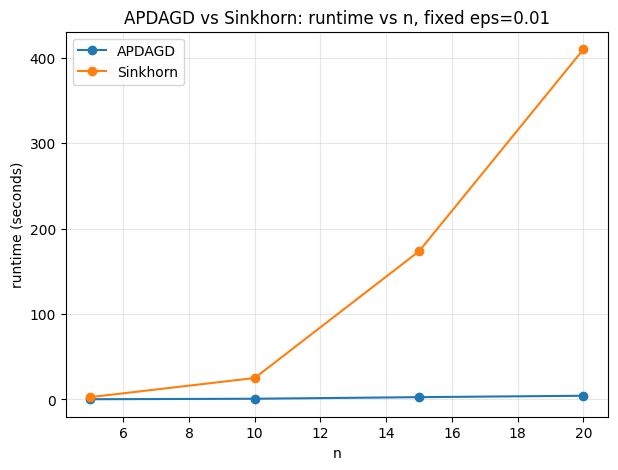

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/sinkhorn_experiment_2_runtime_vs_log_inv_eps.png


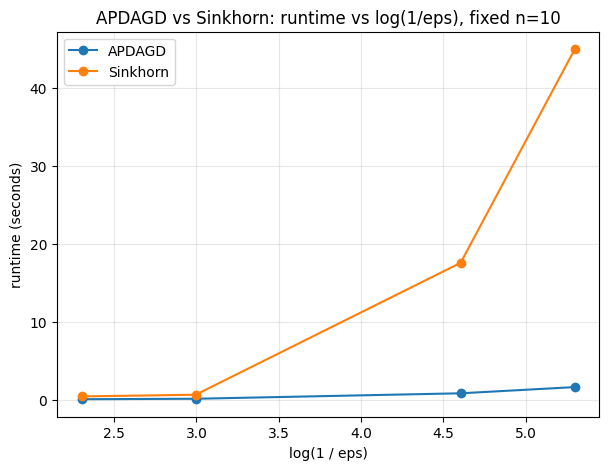

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/sinkhorn_experiment_3_sparsity_vs_n.png


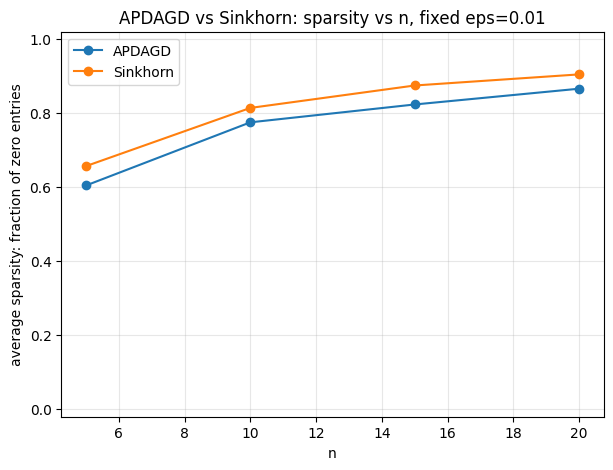

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/sinkhorn_experiment_4_sparsity_vs_log_inv_eps.png


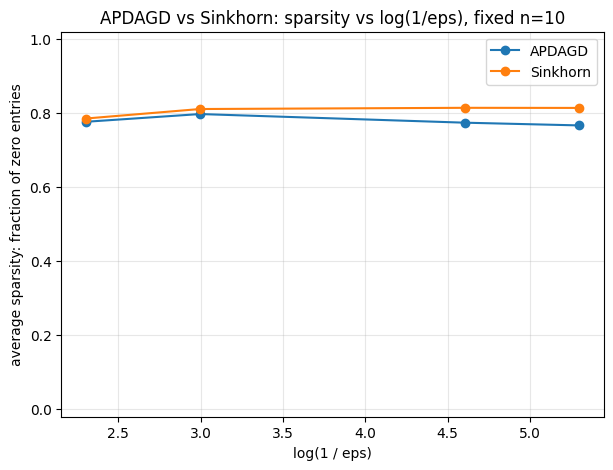

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/sinkhorn_outer_violation_vs_n.png


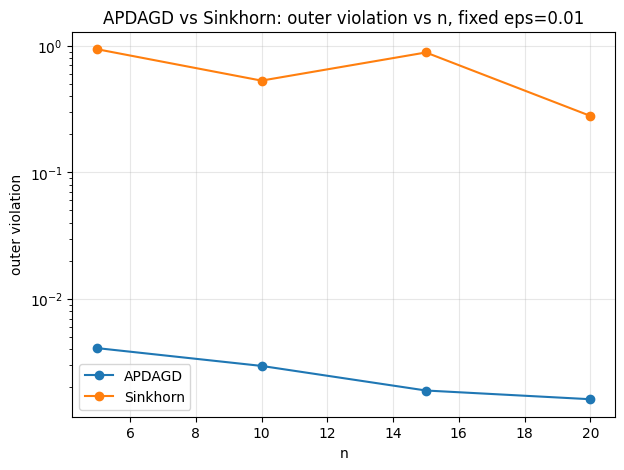

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/sinkhorn_outer_violation_vs_log_inv_eps.png


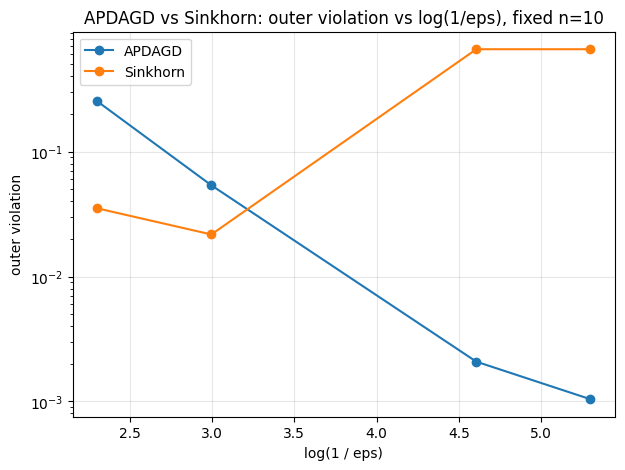

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/sinkhorn_inner_mean_violation_vs_n.png


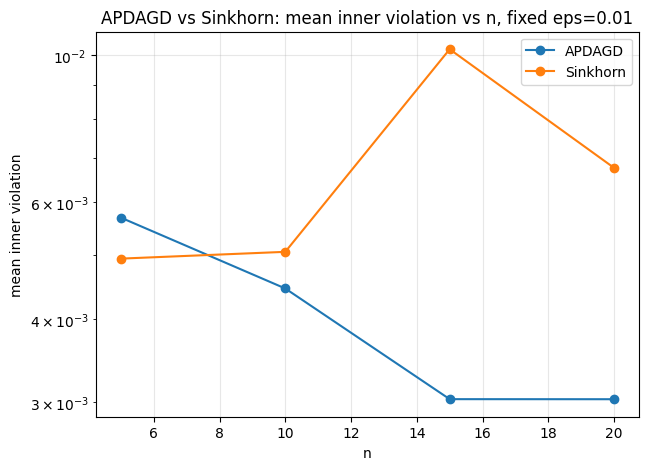

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/sinkhorn_inner_mean_violation_vs_log_inv_eps.png


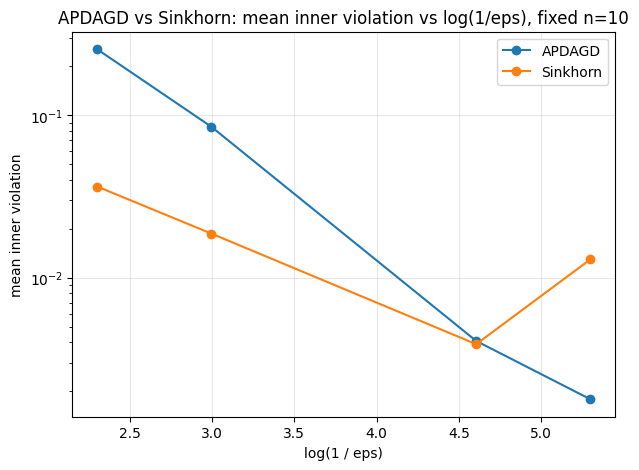

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/sinkhorn_inner_max_violation_vs_n.png


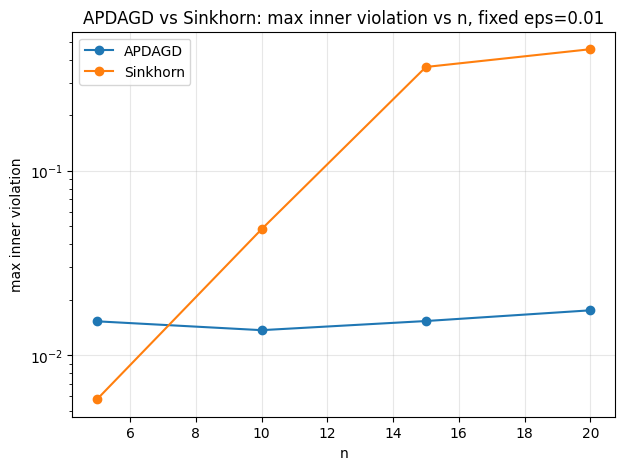

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/sinkhorn_inner_max_violation_vs_log_inv_eps.png


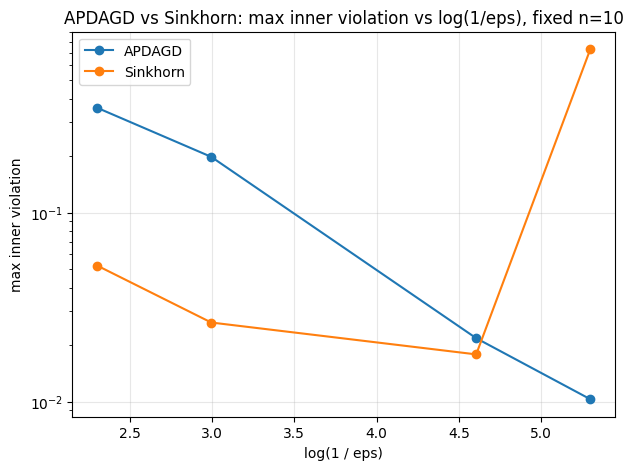

In [12]:
if RUN_EXPERIMENTS:
    print_result_summary(sinkhorn_results_over_n, sinkhorn_solvers)

    plot_metric_vs_n(
        sinkhorn_results_over_n,
        sinkhorn_solvers,
        y_key="runtime",
        ylabel="runtime (seconds)",
        title=f"APDAGD vs Sinkhorn: runtime vs n, fixed eps={fixed_eps:g}",
        filename="sinkhorn_experiment_1_runtime_vs_n.png",
    )
    plot_metric_vs_log_inv_eps(
        sinkhorn_results_over_eps,
        sinkhorn_solvers,
        y_key="runtime",
        ylabel="runtime (seconds)",
        title=f"APDAGD vs Sinkhorn: runtime vs log(1/eps), fixed n={fixed_n}",
        filename="sinkhorn_experiment_2_runtime_vs_log_inv_eps.png",
    )
    plot_metric_vs_n(
        sinkhorn_results_over_n,
        sinkhorn_solvers,
        y_key="avg_sparsity",
        ylabel="average sparsity: fraction of zero entries",
        title=f"APDAGD vs Sinkhorn: sparsity vs n, fixed eps={fixed_eps:g}",
        filename="sinkhorn_experiment_3_sparsity_vs_n.png",
        ylim=(-0.02, 1.02),
    )
    plot_metric_vs_log_inv_eps(
        sinkhorn_results_over_eps,
        sinkhorn_solvers,
        y_key="avg_sparsity",
        ylabel="average sparsity: fraction of zero entries",
        title=f"APDAGD vs Sinkhorn: sparsity vs log(1/eps), fixed n={fixed_n}",
        filename="sinkhorn_experiment_4_sparsity_vs_log_inv_eps.png",
        ylim=(-0.02, 1.02),
    )

    for key, ylabel in [
        ("outer_violation", "outer violation"),
        ("inner_mean_violation", "mean inner violation"),
        ("inner_max_violation", "max inner violation"),
    ]:
        plot_metric_vs_n(
            sinkhorn_results_over_n,
            sinkhorn_solvers,
            y_key=key,
            ylabel=ylabel,
            title=f"APDAGD vs Sinkhorn: {ylabel} vs n, fixed eps={fixed_eps:g}",
            filename=f"sinkhorn_{key}_vs_n.png",
            log_y=True,
        )
        plot_metric_vs_log_inv_eps(
            sinkhorn_results_over_eps,
            sinkhorn_solvers,
            y_key=key,
            ylabel=ylabel,
            title=f"APDAGD vs Sinkhorn: {ylabel} vs log(1/eps), fixed n={fixed_n}",
            filename=f"sinkhorn_{key}_vs_log_inv_eps.png",
            log_y=True,
        )
else:
    print("Skipped plotting. Set RUN_EXPERIMENTS = True and run previous cells first.")

## 10. Plots for comparison B: APDAGD vs Dual L-BFGS

APDAGD
  n= 5, eps=1.0e-02, runtime=0.2231s, avg_sparsity=0.6092, outer_vio=4.085e-03, inner_mean_vio=5.691e-03, inner_max_vio=1.528e-02
  n=10, eps=1.0e-02, runtime=0.7338s, avg_sparsity=0.7799, outer_vio=2.955e-03, inner_mean_vio=4.452e-03, inner_max_vio=1.369e-02
  n=15, eps=1.0e-02, runtime=2.5685s, avg_sparsity=0.8330, outer_vio=1.889e-03, inner_mean_vio=3.033e-03, inner_max_vio=1.534e-02
  n=20, eps=1.0e-02, runtime=4.2904s, avg_sparsity=0.8761, outer_vio=1.612e-03, inner_mean_vio=3.032e-03, inner_max_vio=1.753e-02

Dual L-BFGS
  n= 5, eps=1.0e-02, runtime=0.0809s, avg_sparsity=0.6477, outer_vio=2.443e-05, inner_mean_vio=5.706e-06, inner_max_vio=3.368e-05
  n=10, eps=1.0e-02, runtime=0.4589s, avg_sparsity=0.8106, outer_vio=1.108e-04, inner_mean_vio=9.183e-06, inner_max_vio=4.475e-05
  n=15, eps=1.0e-02, runtime=1.4055s, avg_sparsity=0.8720, outer_vio=2.792e-05, inner_mean_vio=1.068e-05, inner_max_vio=5.023e-05
  n=20, eps=1.0e-02, runtime=2.8223s, avg_sparsity=0.9035, outer_vio=7

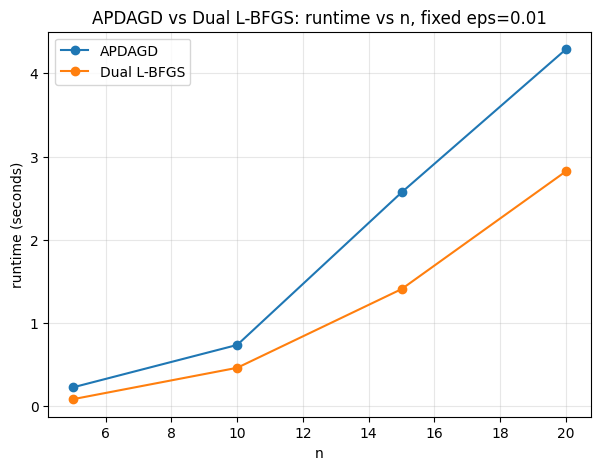

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/dual_experiment_2_runtime_vs_log_inv_eps.png


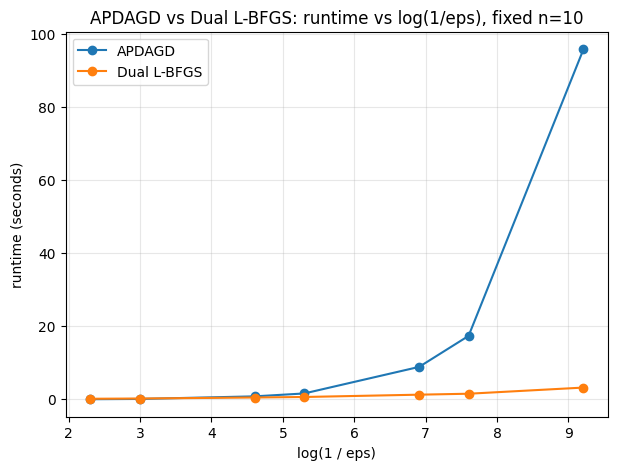

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/dual_experiment_3_sparsity_vs_n.png


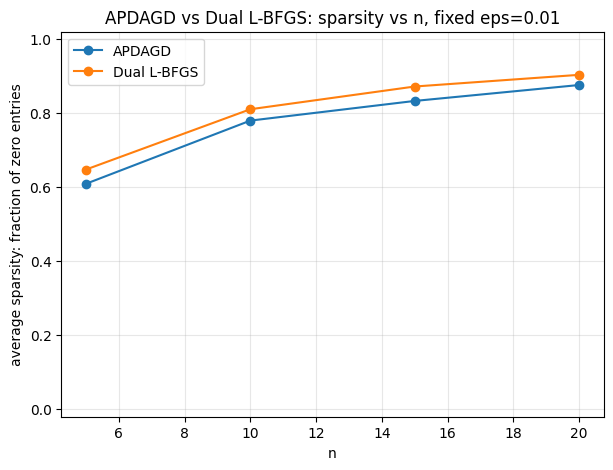

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/dual_experiment_4_sparsity_vs_log_inv_eps.png


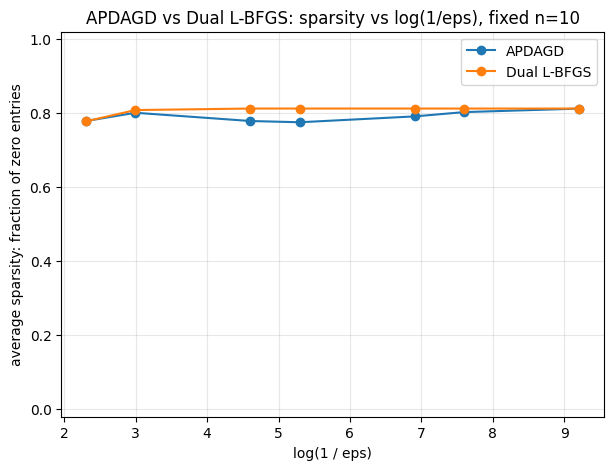

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/dual_outer_violation_vs_n.png


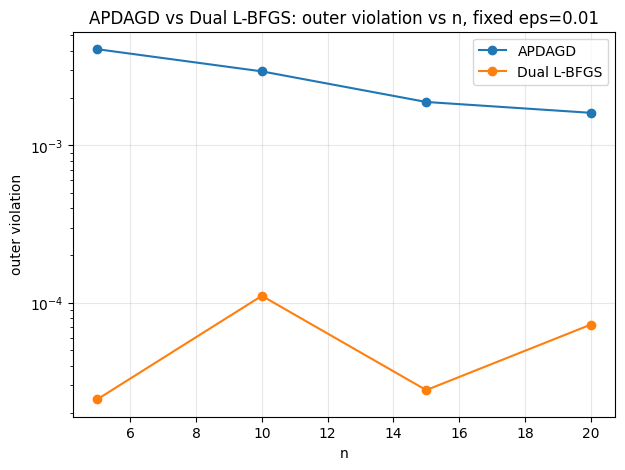

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/dual_outer_violation_vs_log_inv_eps.png


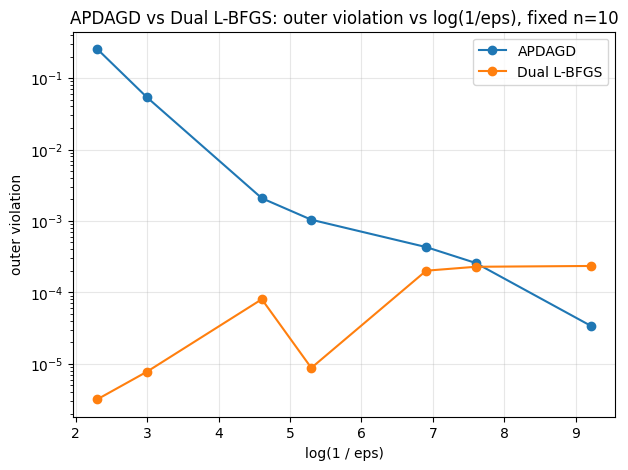

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/dual_inner_mean_violation_vs_n.png


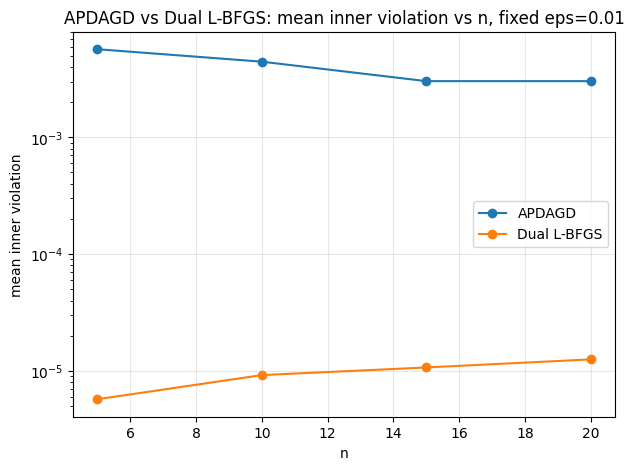

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/dual_inner_mean_violation_vs_log_inv_eps.png


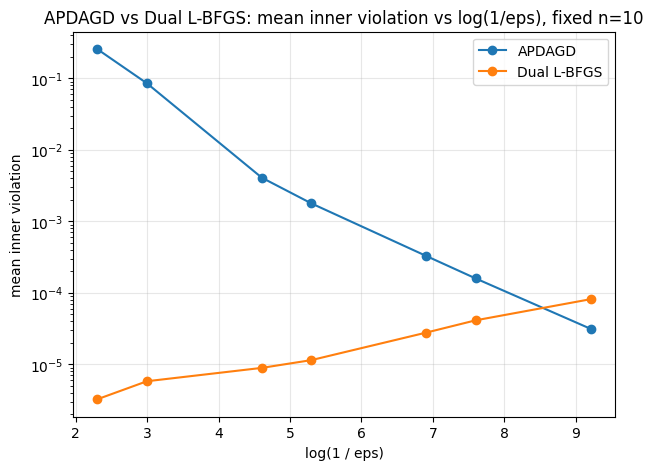

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/dual_inner_max_violation_vs_n.png


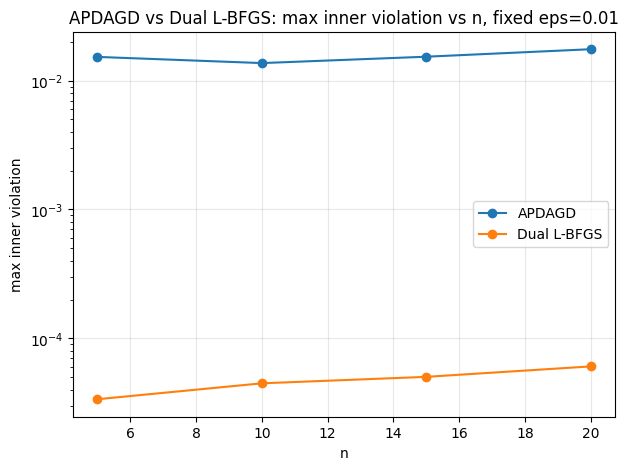

Saved plot to: /Users/zhangyifan/Desktop/nested_ot_comparison/compare/refined_code/plots/dual_inner_max_violation_vs_log_inv_eps.png


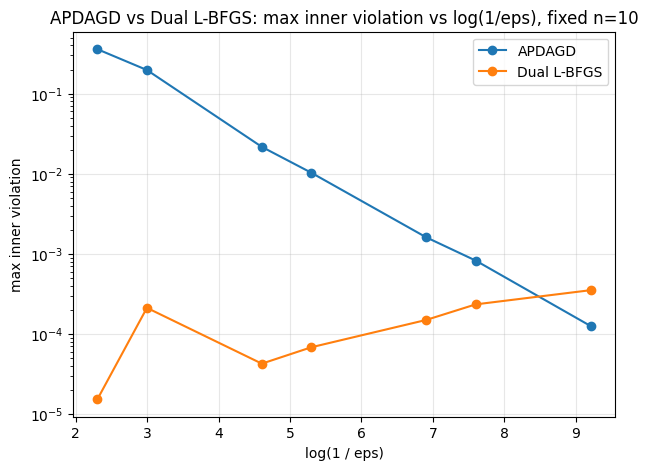

In [13]:
if RUN_EXPERIMENTS:
    print_result_summary(dual_results_over_n, dual_solvers)

    plot_metric_vs_n(
        dual_results_over_n,
        dual_solvers,
        y_key="runtime",
        ylabel="runtime (seconds)",
        title=f"APDAGD vs Dual L-BFGS: runtime vs n, fixed eps={fixed_eps:g}",
        filename="dual_experiment_1_runtime_vs_n.png",
    )
    plot_metric_vs_log_inv_eps(
        dual_results_over_eps,
        dual_solvers,
        y_key="runtime",
        ylabel="runtime (seconds)",
        title=f"APDAGD vs Dual L-BFGS: runtime vs log(1/eps), fixed n={fixed_n}",
        filename="dual_experiment_2_runtime_vs_log_inv_eps.png",
    )
    plot_metric_vs_n(
        dual_results_over_n,
        dual_solvers,
        y_key="avg_sparsity",
        ylabel="average sparsity: fraction of zero entries",
        title=f"APDAGD vs Dual L-BFGS: sparsity vs n, fixed eps={fixed_eps:g}",
        filename="dual_experiment_3_sparsity_vs_n.png",
        ylim=(-0.02, 1.02),
    )
    plot_metric_vs_log_inv_eps(
        dual_results_over_eps,
        dual_solvers,
        y_key="avg_sparsity",
        ylabel="average sparsity: fraction of zero entries",
        title=f"APDAGD vs Dual L-BFGS: sparsity vs log(1/eps), fixed n={fixed_n}",
        filename="dual_experiment_4_sparsity_vs_log_inv_eps.png",
        ylim=(-0.02, 1.02),
    )

    for key, ylabel in [
        ("outer_violation", "outer violation"),
        ("inner_mean_violation", "mean inner violation"),
        ("inner_max_violation", "max inner violation"),
    ]:
        plot_metric_vs_n(
            dual_results_over_n,
            dual_solvers,
            y_key=key,
            ylabel=ylabel,
            title=f"APDAGD vs Dual L-BFGS: {ylabel} vs n, fixed eps={fixed_eps:g}",
            filename=f"dual_{key}_vs_n.png",
            log_y=True,
        )
        plot_metric_vs_log_inv_eps(
            dual_results_over_eps,
            dual_solvers,
            y_key=key,
            ylabel=ylabel,
            title=f"APDAGD vs Dual L-BFGS: {ylabel} vs log(1/eps), fixed n={fixed_n}",
            filename=f"dual_{key}_vs_log_inv_eps.png",
            log_y=True,
        )
else:
    print("Skipped plotting. Set RUN_EXPERIMENTS = True and run previous cells first.")

## 11. Notes for reporting

- Use the same random seed for solvers compared at the same `n` or `eps`.
- The weighted outer OT problem is solved through the same problem interface. For Sinkhorn-type updates, the weighted problem class uses `1 / R_safe` in the coordinate updates.
- The raw coupling outputs are used for sparsity and constraint-violation plots.
- For final paper figures, keep a record of `n_values`, `eps_values_*`, `eta_scale`, iteration budgets, and random seeds.